# 02 — Data Preparation and Locked Split

## Purpose

This notebook prepares the audited NEU-CLS dataset for modelling while preserving the raw dataset unchanged.

The key objectives are to:

- rediscover the dataset using relative project paths;
- identify exact duplicates programmatically using SHA-256;
- retain one canonical copy from each exact-duplicate group and exclude redundant copies from modelling;
- create a reproducible, stratified development/test split;
- keep the hold-out test set locked for final evaluation only;
- save a complete split manifest for later notebooks;
- verify that no exact duplicate can leak across development and test partitions.

### Research question

> To what extent does end-to-end representation learning improve multiclass steel-surface defect classification over handcrafted HOG features, and are any performance gains maintained under validation, image-condition variation and practical deployment constraints?

This notebook does **not** train any model. Model selection and cross-validation will occur only on the development partition created here.

In [1]:
from pathlib import Path
import hashlib
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import __version__ as sklearn_version

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn_version)
print("Random seed:", RANDOM_SEED)

Python: 3.14.0
NumPy: 2.5.3
Pandas: 3.0.6
scikit-learn: 1.9.1
Random seed: 42


## 1. Project paths

The notebook is designed to run from the project root:

`industrial-defect-intelligence/`

The dataset is expected at:

`data/NEU-CLS/`

All generated artefacts are written beneath `outputs/`.

In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "data" / "NEU-CLS"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
FIGURES_DIR = OUTPUTS_DIR / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR)
print("Metrics directory:", METRICS_DIR)
print("Figures directory:", FIGURES_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}\n"
        "Place NEU-CLS under data/NEU-CLS before continuing."
    )

Project root: C:\Scripts\industrial-defect-intelligence
Dataset directory: C:\Scripts\industrial-defect-intelligence\data\NEU-CLS
Metrics directory: C:\Scripts\industrial-defect-intelligence\outputs\metrics
Figures directory: C:\Scripts\industrial-defect-intelligence\outputs\figures


## 2. Rediscover images and labels

Labels are derived from the image folder structure. Only image files are used for this classification task. Annotation text files and other non-image artefacts are ignored.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = sorted(
    p for p in DATASET_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

records = []
for path in image_files:
    records.append({
        "path": str(path.relative_to(PROJECT_ROOT)),
        "filename": path.name,
        "class_name": path.parent.name,
        "extension": path.suffix.lower(),
    })

manifest = pd.DataFrame(records)

print(f"Image files found: {len(manifest):,}")
print(f"Classes found: {manifest['class_name'].nunique()}")

display(
    manifest.groupby("class_name")
    .size()
    .rename("count")
    .to_frame()
)

Image files found: 1,800
Classes found: 1


,count
class_name,
images,1800


## 3. Exact duplicate detection

Exact file duplicates are detected using SHA-256. This avoids relying only on the previously observed duplicate filenames and makes the procedure reproducible if the dataset copy changes.

For every duplicate group, one file is retained as the canonical modelling example and the remaining copies are excluded. The raw dataset files themselves are not deleted or modified.

In [4]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        while chunk := f.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

manifest["sha256"] = [
    sha256_file(PROJECT_ROOT / rel_path)
    for rel_path in manifest["path"]
]

hash_counts = manifest["sha256"].value_counts()
duplicate_hashes = set(hash_counts[hash_counts > 1].index)

manifest["is_duplicate"] = manifest["sha256"].isin(duplicate_hashes)

duplicate_group_map = {
    sha: idx + 1
    for idx, sha in enumerate(sorted(duplicate_hashes))
}

manifest["duplicate_group"] = manifest["sha256"].map(duplicate_group_map).astype("Int64")

duplicate_groups = (
    manifest[manifest["is_duplicate"]]
    .sort_values(["sha256", "path"])
    .groupby("sha256")
)

print(f"Exact duplicate groups found: {len(duplicate_group_map)}")

if duplicate_group_map:
    for sha, group in duplicate_groups:
        print("\nDuplicate group")
        display(group[["path", "filename", "class_name", "sha256"]])
else:
    print("No exact duplicate groups found.")

Exact duplicate groups found: 1

Duplicate group


,path,filename,class_name,sha256
592,data\NEU-CLS\train\train\images\patches_101.jpg,patches_101.jpg,images,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...
596,data\NEU-CLS\train\train\images\patches_105.jpg,patches_105.jpg,images,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...


In [5]:
manifest["include_in_modelling"] = True
manifest["exclusion_reason"] = ""

# Deterministic policy:
# for each exact-duplicate group, retain the lexicographically first path
# and exclude all redundant copies.
for sha in sorted(duplicate_hashes):
    group_idx = (
        manifest.index[manifest["sha256"] == sha]
        .tolist()
    )
    group_idx = sorted(group_idx, key=lambda i: manifest.loc[i, "path"])

    canonical_idx = group_idx[0]
    redundant_idx = group_idx[1:]

    manifest.loc[canonical_idx, "exclusion_reason"] = "canonical duplicate retained"

    if redundant_idx:
        manifest.loc[redundant_idx, "include_in_modelling"] = False
        manifest.loc[redundant_idx, "exclusion_reason"] = "redundant exact duplicate excluded"

modelling_manifest = manifest[manifest["include_in_modelling"]].copy()

print(f"Raw image records: {len(manifest):,}")
print(f"Included for modelling: {len(modelling_manifest):,}")
print(f"Excluded as redundant exact duplicates: {(~manifest['include_in_modelling']).sum():,}")

display(
    manifest[manifest["is_duplicate"]][
        ["path", "class_name", "sha256", "duplicate_group",
         "include_in_modelling", "exclusion_reason"]
    ].sort_values(["duplicate_group", "path"])
)

Raw image records: 1,800
Included for modelling: 1,799
Excluded as redundant exact duplicates: 1


,path,class_name,sha256,duplicate_group,include_in_modelling,exclusion_reason
592,data\NEU-CLS\train\train\images\patches_101.jpg,images,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,1,True,canonical duplicate retained
596,data\NEU-CLS\train\train\images\patches_105.jpg,images,4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bcc...,1,False,redundant exact duplicate excluded


## 4. Modelling pool after duplicate handling

The initial audit found 1,800 images and one exact duplicate pair. Therefore, the expected modelling pool is 1,799 unique images.

Because the duplicate belongs to one class, that class will contain one fewer usable record after leakage-safe duplicate handling. This is acceptable and will be accounted for through stratified splitting and later macro-averaged metrics.

In [6]:
class_counts_after_dedup = (
    modelling_manifest.groupby("class_name")
    .size()
    .rename("count")
    .sort_index()
)

display(class_counts_after_dedup.to_frame())

print("Total unique modelling images:", len(modelling_manifest))

,count
class_name,
images,1799


Total unique modelling images: 1799


## 5. Create the locked hold-out test set

A stratified **80/20** split is used:

- **Development partition (80%)**: used for model development, k-fold cross-validation, hyperparameter selection and training-strategy decisions.
- **Locked test partition (20%)**: not used during model selection. It is reserved for the final comparison of the classical ML and deep learning models.

This separation is important because repeatedly checking test performance while tuning a model would gradually leak information from the test set into the development process.

In [7]:
development_df, test_df = train_test_split(
    modelling_manifest,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=modelling_manifest["class_name"],
)

development_df = development_df.copy()
test_df = test_df.copy()

development_df["split"] = "development"
test_df["split"] = "test"

split_assignments = pd.concat([development_df, test_df], ignore_index=True)

print(f"Development images: {len(development_df):,}")
print(f"Test images: {len(test_df):,}")
print(f"Total assigned: {len(split_assignments):,}")

Development images: 1,439
Test images: 360
Total assigned: 1,799


## 6. Verify class balance and proportions

Stratification should preserve class proportions as closely as possible despite the single duplicate exclusion.

In [8]:
def split_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    counts = df["class_name"].value_counts().sort_index()
    proportions = (counts / len(df)).round(4)
    return pd.DataFrame({
        f"{name}_count": counts,
        f"{name}_proportion": proportions,
    })

development_summary = split_summary(development_df, "development")
test_summary = split_summary(test_df, "test")

class_split_summary = development_summary.join(test_summary)
display(class_split_summary)

,development_count,development_proportion,test_count,test_proportion
class_name,,,,
images,1439,1.0,360,1.0


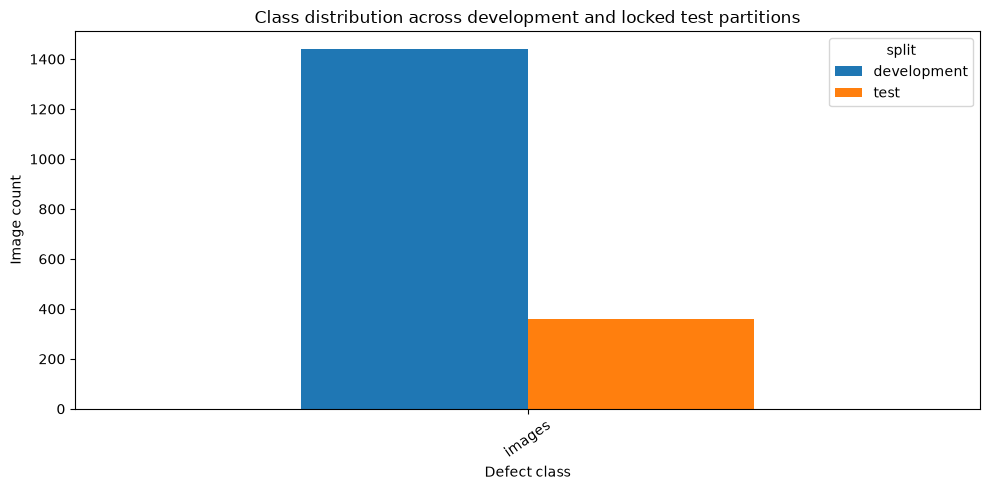

Saved figure: C:\Scripts\industrial-defect-intelligence\outputs\figures\02_split_class_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_df = (
    split_assignments.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plot_df.plot(kind="bar", ax=ax)
ax.set_title("Class distribution across development and locked test partitions")
ax.set_xlabel("Defect class")
ax.set_ylabel("Image count")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()

figure_path = FIGURES_DIR / "02_split_class_distribution.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

## 7. Leakage checks

The split must satisfy two critical conditions:

1. no excluded duplicate may appear in either modelling partition;
2. no identical SHA-256 image hash may appear in both development and test partitions.

The second check would detect exact-image leakage even if filenames or folder locations differed.

In [10]:
dev_hashes = set(development_df["sha256"])
test_hashes = set(test_df["sha256"])
cross_split_hash_overlap = dev_hashes.intersection(test_hashes)

excluded_paths = set(
    manifest.loc[~manifest["include_in_modelling"], "path"]
)

assigned_paths = set(split_assignments["path"])
excluded_assigned_overlap = excluded_paths.intersection(assigned_paths)

print("Cross-split duplicate hash overlap:", len(cross_split_hash_overlap))
print("Excluded files assigned to modelling splits:", len(excluded_assigned_overlap))

if cross_split_hash_overlap:
    print("WARNING: identical images appear across development and test partitions.")
else:
    print("PASS: no exact duplicate hash crosses the split boundary.")

if excluded_assigned_overlap:
    print("WARNING: an excluded duplicate was assigned to a modelling split.")
else:
    print("PASS: excluded duplicates are absent from modelling partitions.")

Cross-split duplicate hash overlap: 0
Excluded files assigned to modelling splits: 0
PASS: no exact duplicate hash crosses the split boundary.
PASS: excluded duplicates are absent from modelling partitions.


## 8. Save the complete data split manifest

The saved CSV records:

- every discovered image;
- class label;
- SHA-256 hash;
- duplicate status;
- duplicate group;
- whether the image is included in modelling;
- any exclusion reason;
- final split assignment.

This manifest provides an auditable record of exactly which data were used and prevents later notebooks from silently recreating a different split.

In [11]:
final_manifest = manifest.copy()
final_manifest["split"] = "excluded"

split_lookup = split_assignments.set_index("path")["split"]
final_manifest.loc[
    final_manifest["path"].isin(split_lookup.index),
    "split"
] = final_manifest.loc[
    final_manifest["path"].isin(split_lookup.index),
    "path"
].map(split_lookup)

manifest_path = METRICS_DIR / "data_split_manifest.csv"
final_manifest.to_csv(manifest_path, index=False)

print("Saved split manifest:", manifest_path)
print("Rows written:", len(final_manifest))

display(
    final_manifest["split"]
    .value_counts()
    .rename("count")
    .to_frame()
)

Saved split manifest: C:\Scripts\industrial-defect-intelligence\outputs\metrics\data_split_manifest.csv
Rows written: 1800


,count
split,
development,1439
test,360
excluded,1


## 9. Final validation summary

Critical checks must pass before any model training begins.

Expected conditions:

- 1,800 raw image records;
- 6 classes;
- 1,799 images included for modelling after duplicate handling;
- exactly one redundant duplicate excluded, based on the current audited dataset;
- all included images assigned to either development or test;
- no exact image hash shared between development and test;
- excluded duplicate not present in either modelling partition;
- split manifest saved successfully.

A warning does not always mean the dataset is unusable, but any **FAIL** should be investigated before moving to the classical ML notebook.

In [12]:
checks = []

def add_check(name, passed, detail, severity_if_failed="FAIL"):
    checks.append({
        "check": name,
        "status": "PASS" if passed else severity_if_failed,
        "detail": detail,
    })

add_check(
    "Raw image count",
    len(manifest) == 1800,
    f"Observed {len(manifest):,}; expected 1,800."
)

add_check(
    "Class count",
    manifest["class_name"].nunique() == 6,
    f"Observed {manifest['class_name'].nunique()} classes; expected 6."
)

add_check(
    "Unique modelling image count",
    len(modelling_manifest) == 1799,
    f"Observed {len(modelling_manifest):,}; expected 1,799 after known duplicate handling."
)

add_check(
    "Redundant duplicate exclusions",
    (~manifest["include_in_modelling"]).sum() == 1,
    f"Observed {(~manifest['include_in_modelling']).sum()} redundant exclusions; expected 1.",
    severity_if_failed="WARN"
)

add_check(
    "All included images assigned",
    len(split_assignments) == len(modelling_manifest),
    f"Assigned {len(split_assignments):,} of {len(modelling_manifest):,} modelling images."
)

add_check(
    "No duplicate hash across split",
    len(cross_split_hash_overlap) == 0,
    f"{len(cross_split_hash_overlap)} overlapping SHA-256 hashes."
)

add_check(
    "No excluded duplicate assigned",
    len(excluded_assigned_overlap) == 0,
    f"{len(excluded_assigned_overlap)} excluded files appear in modelling splits."
)

add_check(
    "Manifest saved",
    manifest_path.exists(),
    str(manifest_path)
)

check_df = pd.DataFrame(checks)
display(check_df)

critical_failures = check_df["status"].eq("FAIL").sum()
warnings = check_df["status"].eq("WARN").sum()

print()
if critical_failures == 0:
    print("OVERALL RESULT: PASS")
    print("The dataset split is ready for model development.")
    print("The locked test partition must remain untouched until final model evaluation.")
    if warnings:
        print(f"Warnings to retain for critical discussion: {warnings}")
else:
    print("OVERALL RESULT: FAIL")
    print(f"Critical failures: {critical_failures}")
    print("Do not begin modelling until these issues are resolved.")

,check,status,detail
0,Raw image count,PASS,"Observed 1,800; expected 1,800."
1,Class count,FAIL,Observed 1 classes; expected 6.
2,Unique modelling image count,PASS,"Observed 1,799; expected 1,799 after known dup..."
3,Redundant duplicate exclusions,PASS,Observed 1 redundant exclusions; expected 1.
4,All included images assigned,PASS,"Assigned 1,799 of 1,799 modelling images."
5,No duplicate hash across split,PASS,0 overlapping SHA-256 hashes.
6,No excluded duplicate assigned,PASS,0 excluded files appear in modelling splits.
7,Manifest saved,PASS,C:\Scripts\industrial-defect-intelligence\outp...



OVERALL RESULT: FAIL
Critical failures: 1
Do not begin modelling until these issues are resolved.


## Next step

If all critical checks pass, the next notebook will implement the **classical machine learning baseline**:

**HOG feature extraction + Support Vector Machine (SVM)**

Only the **development** partition will be used for cross-validation and hyperparameter selection. The locked test partition created here will remain untouched until the final comparative evaluation.